# Parameters

In [1]:
import sys
import os
from pathlib import Path
import pandas as pd

# ===== CONFIGURAÇÃO DE CAMINHOS =====
current_notebook = Path.cwd()  
project_root = current_notebook.parent.parent 

# Adiciona o diretório raiz ao sys.path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Adiciona o diretório Modules ao sys.path
modules_dir = project_root / "Modules"
if str(modules_dir) not in sys.path:
    sys.path.insert(0, str(modules_dir))

# ===== IMPORTS DOS MÓDULOS =====
import Modules.ClusterKmeansModule as cluster
import Modules.FutureAnalysisModule as fa
from Modules.config import CONFIG

# ===== CONFIGURAÇÕES DO PROJETO =====
DATAPATH = CONFIG["datapath"]
COVID_TRAIN_DATA_FILE = CONFIG["covid_train_data_file"]
COVID_TEST_DATA_FILE = CONFIG["covid_test_data_file"]
FUTURE_DATA_FILE = CONFIG["future_data_file"]

FIGSIZE_CLUSTER_HEATMAP = CONFIG["figsize_cluster_heatmap"]
FIGSIZE_FUTURE_HEATMAP = CONFIG["figsize_future_heatmap"]
IMAGES_SAVE_PATH = CONFIG["image_save_path"]

# Import data

In [2]:
# ===== CARREGAMENTO DOS DADOS =====
data_folder = current_notebook / DATAPATH

covid_train = pd.read_csv(data_folder / COVID_TRAIN_DATA_FILE)
covid_test = pd.read_csv(data_folder / COVID_TEST_DATA_FILE)
future_data = pd.read_csv(data_folder / FUTURE_DATA_FILE)

# Feature engineering: morte após a internação
covid_train['died_after'] = ((covid_train['died'] == 1) & (covid_train['died_in_stay'] == 0)).astype(int)
covid_test['died_after'] = ((covid_test['died'] == 1) & (covid_test['died_in_stay'] == 0)).astype(int)
future_data['died_after'] = ((future_data['died'] == 1) & (future_data['died_in_stay'] == 0)).astype(int)

In [3]:
data_covid = pd.concat([covid_train, covid_test], axis=0)
data_covid = data_covid.sample(frac=1, random_state=42).reset_index(drop=True)

# Mice Data

In [4]:
categorical_features = [
            "myocardial_infarct",
            "congestive_heart_failure",
            "peripheral_vascular_disease",
            "cerebrovascular_disease",
            "dementia",
            "chronic_pulmonary_disease",
            "rheumatic_disease",
            "peptic_ulcer_disease",
            "mild_liver_disease",
            "diabetes_without_cc",
            "diabetes_with_cc",
            "paraplegia",
            "renal_disease",
            "malignant_cancer",
            "severe_liver_disease",
            "metastatic_solid_tumor",
            "aids",
            "gender_M",
            "died_in_stay",
            "died_after",
            "died",
            "COVID"
        ]

In [5]:
features_not_considered = ["died", "died_in_stay", "died_after", "COVID", "subject_id", "hadm_id"]

In [6]:
helper = cluster.KmeansClusterHelper(data=data_covid, features_not_considered=features_not_considered, scaler= "standard")

2026-02-24 12:35:25,760 - ClusterBaseModule - INFO - ClusterBaseHelper initialized: 3355 records, 67 features (22 categorical, 51 numerical)
2026-02-24 12:35:25,761 - Modules.ClusterKmeansModule - INFO - KmeansClusterHelper initialized: 3355 records, 67 features


## Find best K-means

### K-means

Calculating metrics per k:   0%|          | 0/9 [00:00<?, ?it/s]

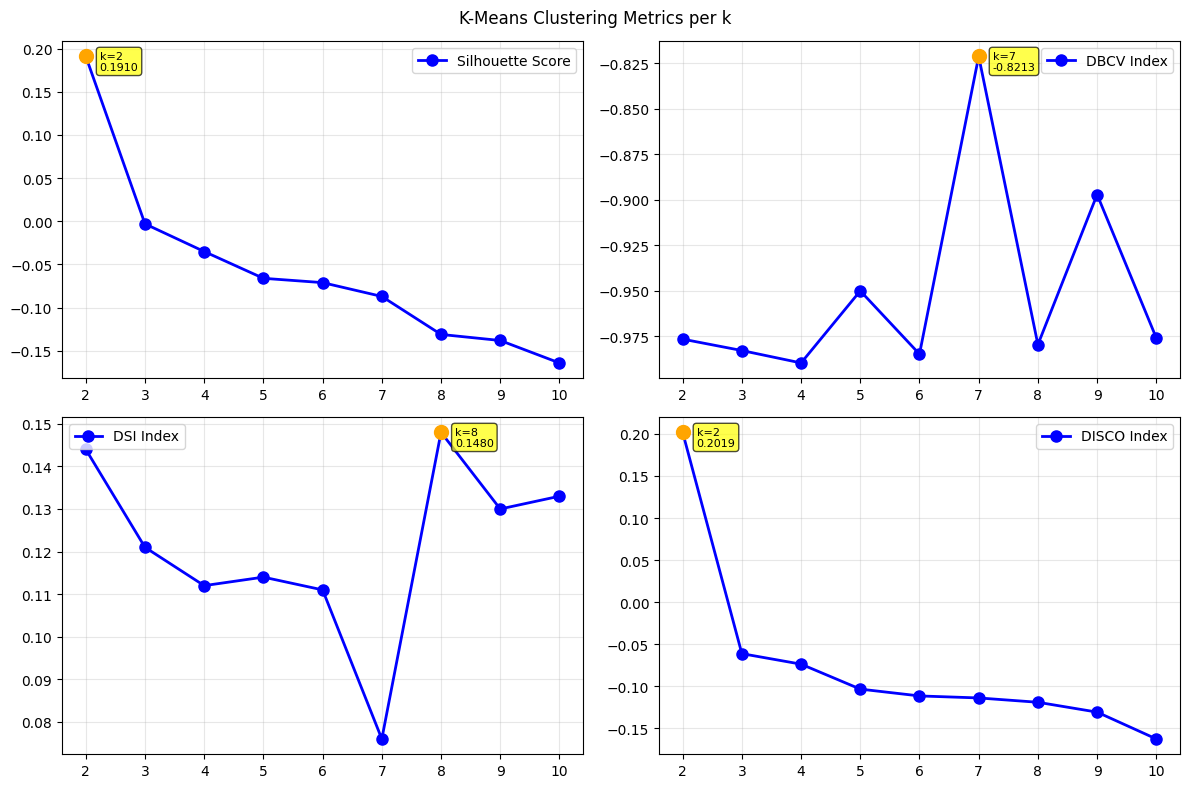

In [7]:
os.environ['PYTHONWARNINGS'] = 'ignore'
helper.metrics_per_k(scaleCategorical = False, figsize=(12,8), dimensionality_reduction={"method": "PCA", "dimensions": 30})

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:29<00:00,  3.37it/s]


Calculating metrics per k:   0%|          | 0/9 [00:00<?, ?it/s]

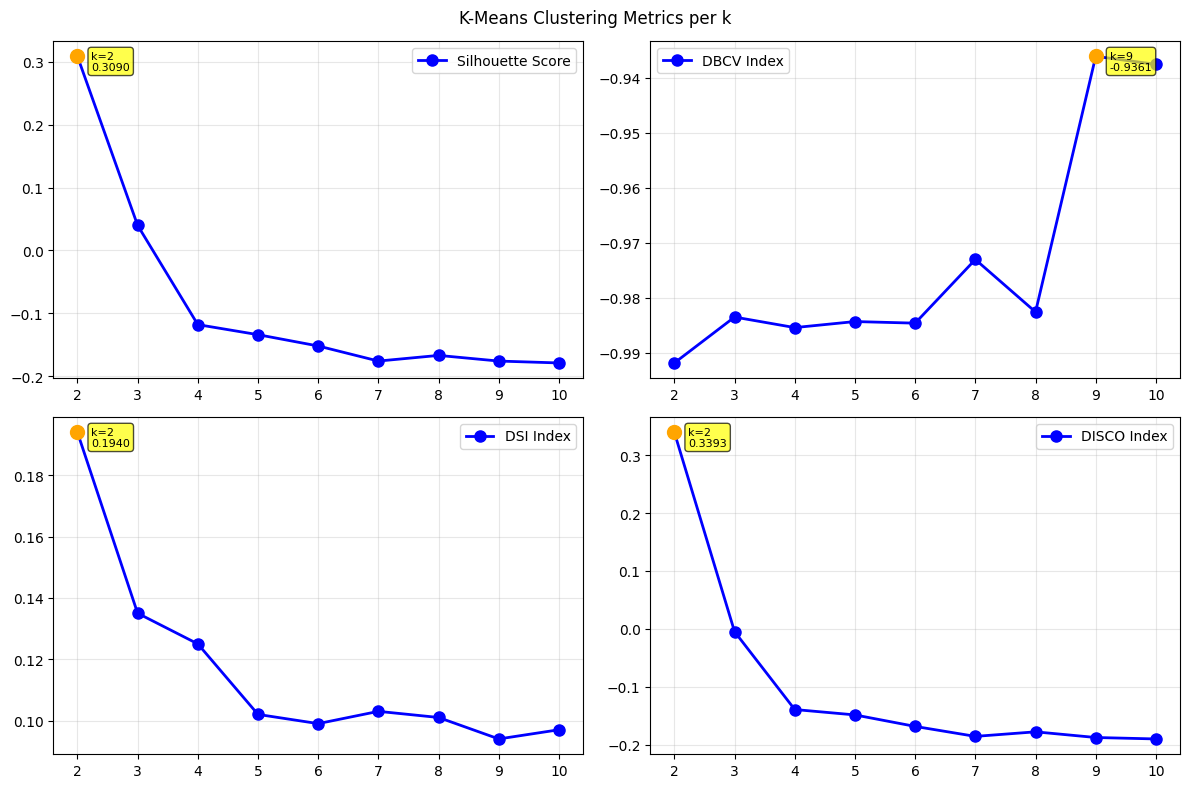

In [8]:
helper.metrics_per_k(scaleCategorical = False, figsize=(12,8), dimensionality_reduction={"method": "AE", "dimensions": 10})

## K-means with PCA

### K = 2

In [7]:
helper.k_means(k=2, dimensionality_reduction={"method": "PCA", "dimensions": 30})
metrics = helper.get_metrics()

2026-02-24 12:35:29,242 - ClusterBaseModule - INFO - Applied PCA reduction to 30 dimensions


2026-02-24 12:35:29,296 - Modules.ClusterKmeansModule - INFO - K-Means clustering completed: k=2, inertia=142407.46
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
2026-02-24 12:35:34,415 - ClusterBaseModule - INFO - Calculated metrics: silhouette=0.191, dbcv=-0.977, dsi=0.144, disco=0.202


## K-means with Autoencoder

### K = 2

In [8]:
helper.k_means(k=2, dimensionality_reduction={"method": "AE", "dimensions": 10})
metrics = helper.get_metrics()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:26<00:00,  3.79it/s]


2026-02-24 12:36:01,259 - ClusterBaseModule - INFO - Applied Autoencoder reduction to 10 dimensions
2026-02-24 12:36:01,266 - Modules.ClusterKmeansModule - INFO - K-Means clustering completed: k=2, inertia=9555.11
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
2026-02-24 12:36:06,638 - ClusterBaseModule - INFO - Calculated metrics: silhouette=0.309, dbcv=-0.992, dsi=0.194, disco=0.339


2026-02-24 12:36:09,373 - ClusterBaseModule - INFO - Calculated categorical stats for 2 clusters


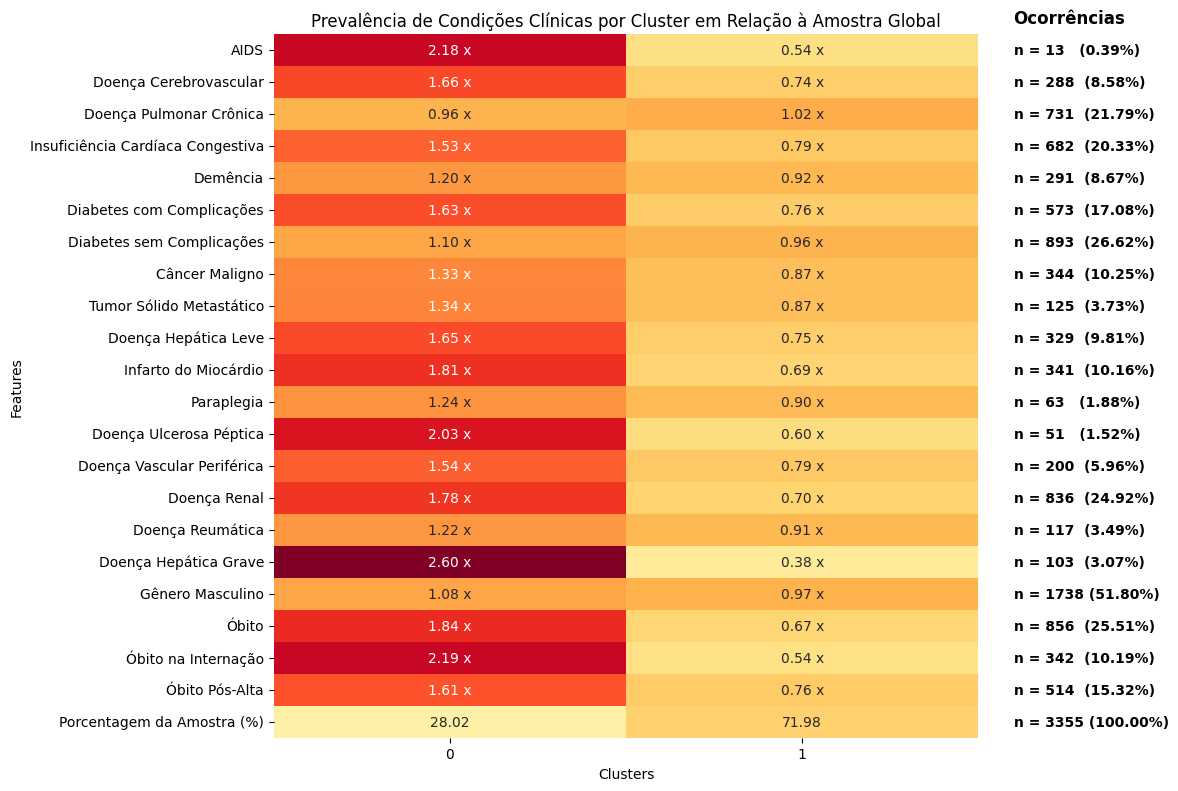

2026-02-24 12:36:09,559 - ClusterBaseModule - INFO - Created categorical heatmap: 22 features, 2 clusters


In [9]:
helper.heatmap_clusters_categorical(
    figsize=FIGSIZE_CLUSTER_HEATMAP, 
    relative_total=True
    # savepath=IMAGES_SAVE_PATH + "kmeans-dr-categorical"
)

In [12]:
selectedClusters = [0, 1]

In [13]:
helper.setClusteredAutoencoder()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:27<00:00,  3.62it/s]


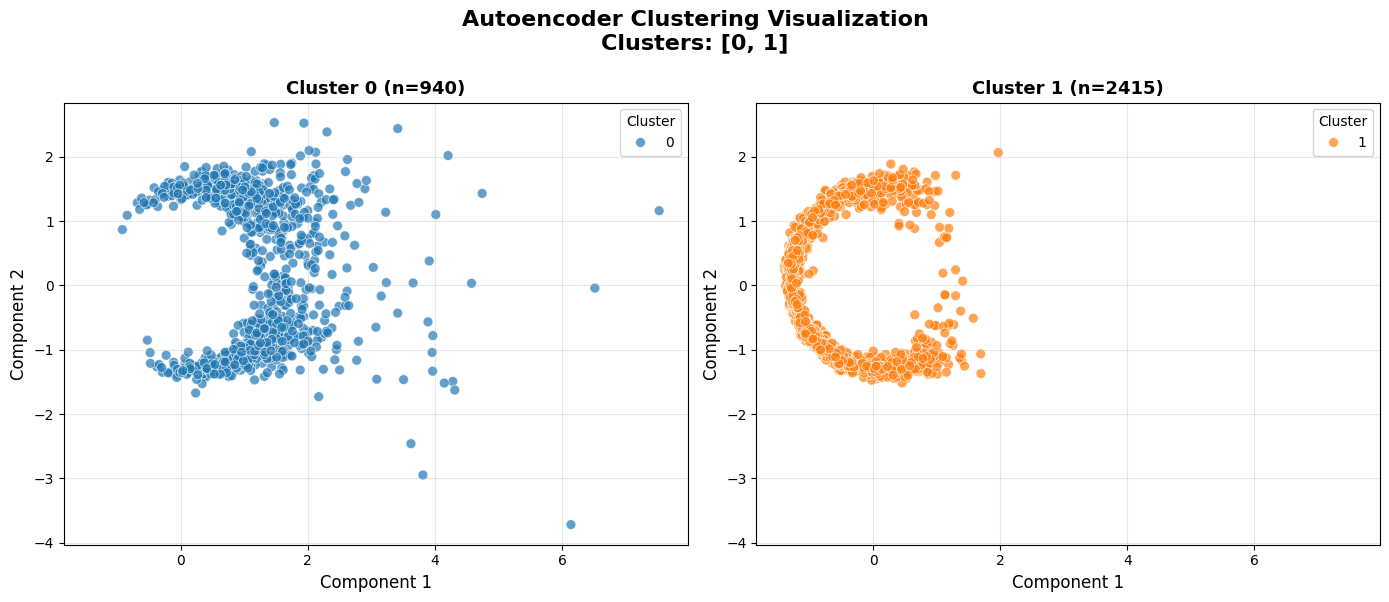

In [14]:
helper.showClusteredAutoencoder(selectedClusters=selectedClusters, savepath=IMAGES_SAVE_PATH + "kmeans-autoencoder-dr")

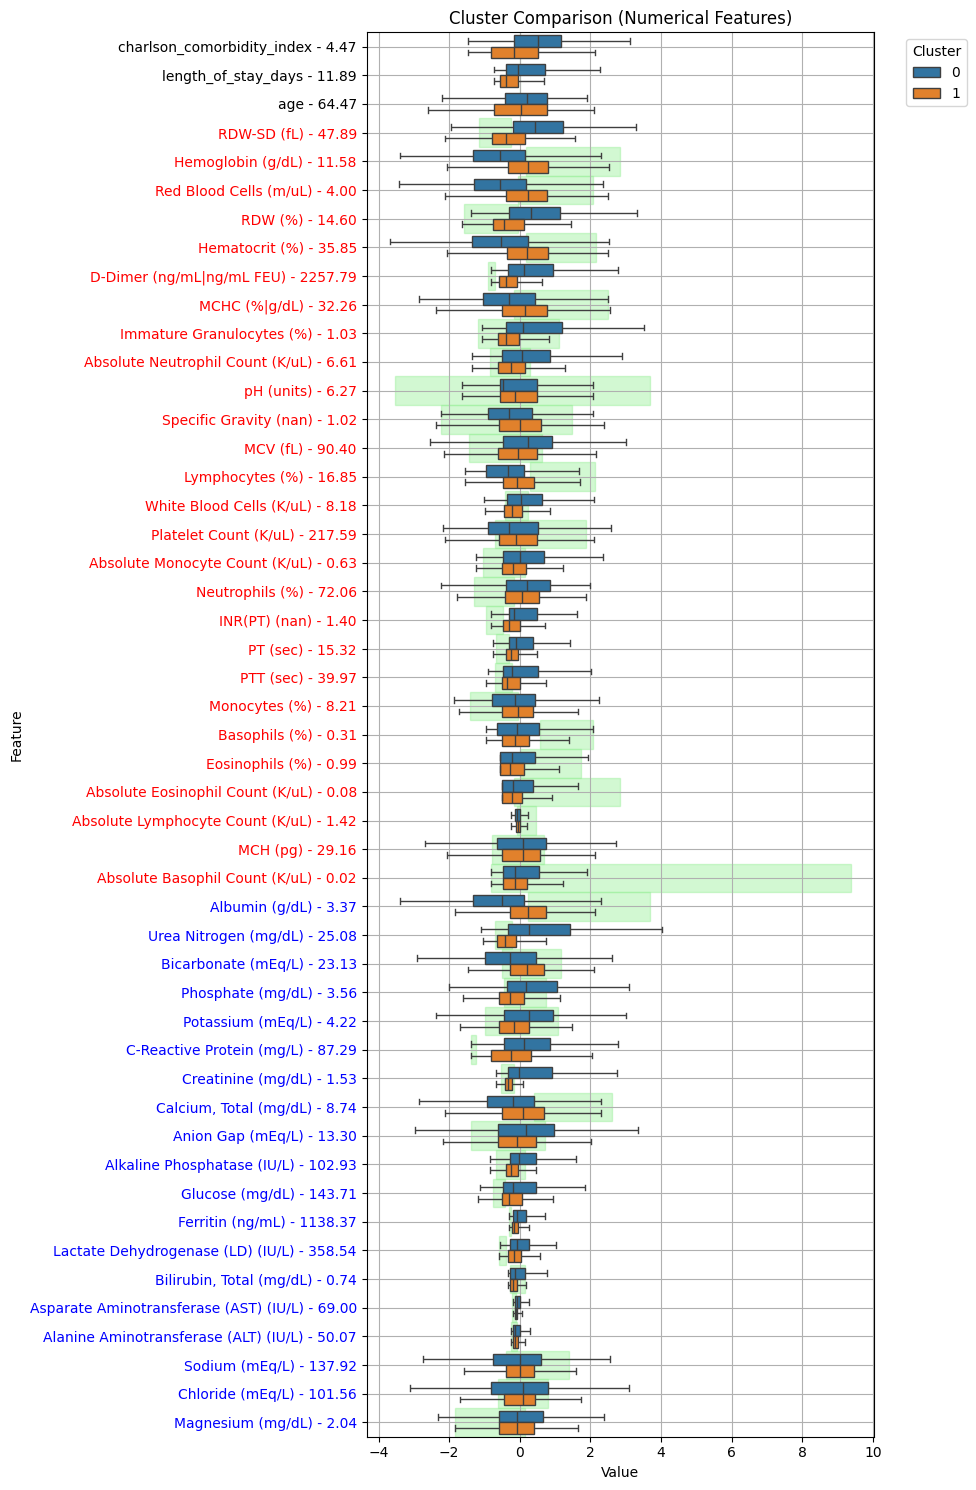

[]

In [15]:
helper.showClusterCompareNumerical(
    scaled="standard",
    topFeatures=-1,
    max_features=-1,
    selectedClusters=selectedClusters,
    figsize=(10, 15),
    savepath=IMAGES_SAVE_PATH + "kmeans-dr-numerical", verbose=1)

#### Future data


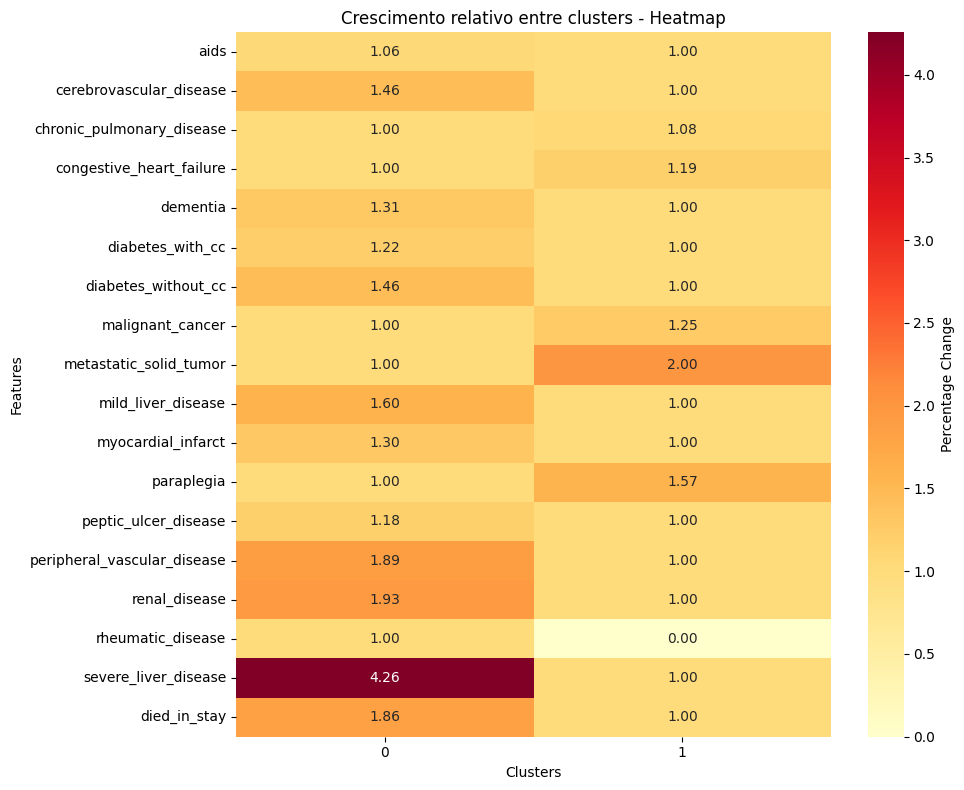

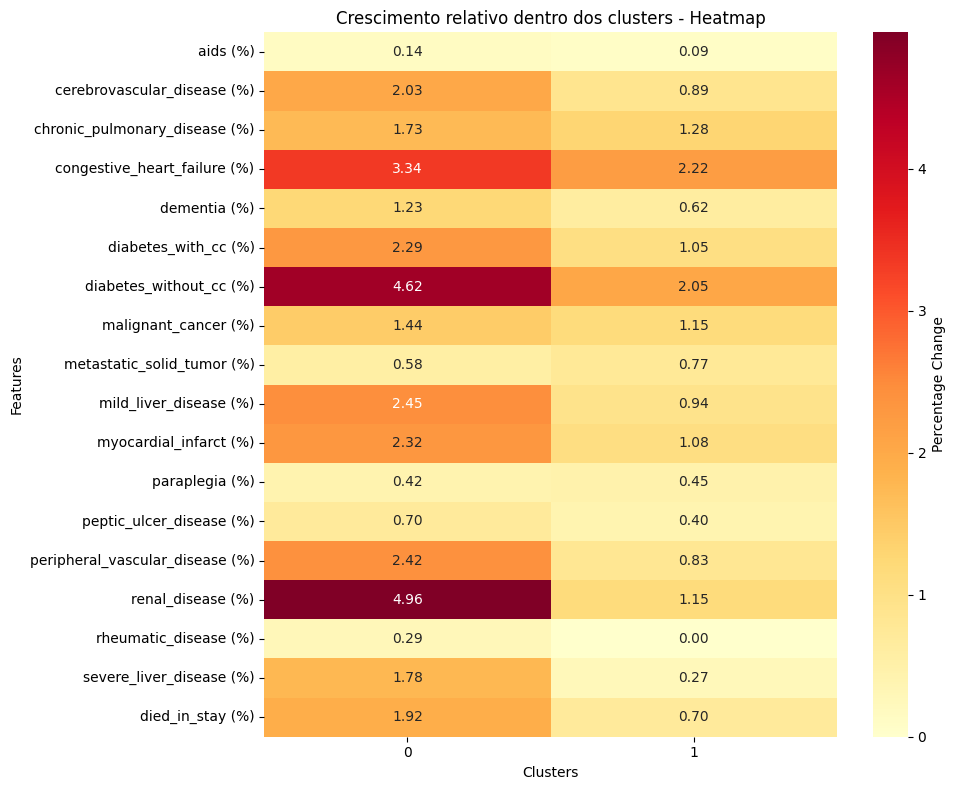

In [16]:
future_helper = fa.FutureAnalysisHelper(helper.clusteredData, future_data)
future_helper.insertClustersInFutureData(onlyFirstAdmission=True)
delta = future_helper.getDeltaClusters(percentage=True, metric="externo")
future_helper.showDeltaHeatmap(
    figsize=FIGSIZE_FUTURE_HEATMAP,
    selectedClusters=selectedClusters,
    savepath=IMAGES_SAVE_PATH + "kmeans-dr-externo",
    metric="externo",
)
delta = future_helper.getDeltaClusters(percentage=True, metric="interno")
future_helper.showDeltaHeatmap(
    figsize=FIGSIZE_FUTURE_HEATMAP,
    selectedClusters=selectedClusters,
    savepath=IMAGES_SAVE_PATH + "kmeans-dr-interno",
    metric="interno",
)

In [17]:
future_helper.getMeanReadmission()

{'Mean readmission Cluster 0': 2.53,
 'Mean readmission Cluster 1': 2.21,
 'Overall Mean readmission': 2.31}

In [18]:
future_helper.getMeanDaysGap()

{'Mean days gap Cluster 0': 129.25,
 'Mean days gap Cluster 1': 126.66,
 'Overall Mean days gap': 127.49}

In [19]:
future_helper.getMortalityRates(onlyFirstAdmission=True)

{'Mortality rate Cluster 0': 0.07,
 'Mortality rate Cluster 1': 0.12,
 'Overall Mortality rate': 0.09}

# Add log

In [22]:
log_file = "../log.csv"
current_dir = os.getcwd()
log_file_path = os.path.join(current_dir, log_file)

# Add line to save log
if os.path.exists(log_file_path):
    with open(log_file_path, 'a') as f:
        f.write(f"K-means, Autoencoder, Comprehensive, {metrics['disco']}, {metrics['dbcv']}, {metrics['dsi']}, {metrics['silhouette']}\n")